In [1]:
import numpy as np
import pandas as pd
import shap
import joblib
import sqlite3
from datetime import datetime

C:\Users\01\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
conn = sqlite3.connect(r"C:\Users\01\problem\database/project_current.db")

In [3]:
students = pd.read_excel(r"C:\Users\01\problem\dataset\data\current\student_master.xlsx")
attendance = pd.read_excel(r"C:\Users\01\problem\dataset\data\current\attendance_data.xlsx")
assessments = pd.read_excel(r"C:\Users\01\problem\dataset\data\current\assessment_data.xlsx")
fees = pd.read_excel(r"C:\Users\01\problem\dataset\data\current\fee_payment_data.xlsx")

In [4]:
students.to_sql("students",conn,if_exists="replace",index=False)
attendance.to_sql("attendance",conn,if_exists="replace",index=False)
assessments.to_sql("assessments",conn,if_exists="replace",index=False)
fees.to_sql("fees",conn,if_exists="replace",index=False)

2000

In [5]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'",conn)

In [6]:
df = (students
    .merge(attendance, on="student_id", how="left")
    .merge(assessments, on="student_id", how="left")
    .merge(fees, on="student_id", how="left"))

In [7]:
final_model = joblib.load("student_risk_model_previous.pkl")
threshold = joblib.load("threshold.pkl")
expected_columns = joblib.load("expected_columns.pkl")
scores = joblib.load("scores.pkl")
obj_col = joblib.load("obj_col.pkl")

In [8]:
current_attendance = ['attendance_pct_Feb_2026','attendance_pct_Mar_2026','attendance_pct_Apr_2026',
                      'attendance_pct_May_2026','attendance_pct_Jun_2026','attendance_pct_Jul_2026']

In [9]:
monthly_attendance = ['attendance_pct_Feb_2025','attendance_pct_Mar_2025','attendance_pct_Apr_2025',
                      'attendance_pct_May_2025','attendance_pct_Jun_2025','attendance_pct_Jul_2025']

In [10]:
attendance_mapping = dict(zip(monthly_attendance,current_attendance[:len(monthly_attendance)]))

In [11]:
preprocessor = final_model.named_steps['preprocessor']

In [12]:
model = final_model.named_steps['model']

In [13]:
X_current = df.copy()

In [14]:
for old_col, current_col in attendance_mapping.items():
    X_current[old_col] = df[current_col]

In [15]:
x_current = X_current[expected_columns].copy()

In [16]:
x_current = x_current[expected_columns]

In [17]:
y_current_prob = final_model.predict_proba(x_current)[:,1]

In [18]:
y_current_pred = (y_current_prob>=threshold).astype(int)

In [19]:
df['dropout_prob'] = y_current_prob
df['dropout_pred'] = y_current_pred

In [20]:
data = pd.DataFrame({
    "student_id": df["student_id"],
    "dropout_prob": y_current_prob,
    "dropout_pred": y_current_pred
})

In [21]:
data.head()

,student_id,dropout_prob,dropout_pred
0,STU10000,0.018257,0
1,STU10001,0.064768,0
2,STU10002,0.068680,0
3,STU10003,0.016900,0
4,STU10004,0.720823,1


In [22]:
x_current_transformed = preprocessor.transform(x_current)

In [23]:
feature_names = preprocessor.get_feature_names_out()

In [24]:
explainer = shap.TreeExplainer(model)

In [25]:
curr_shap_values = explainer.shap_values(x_current_transformed)

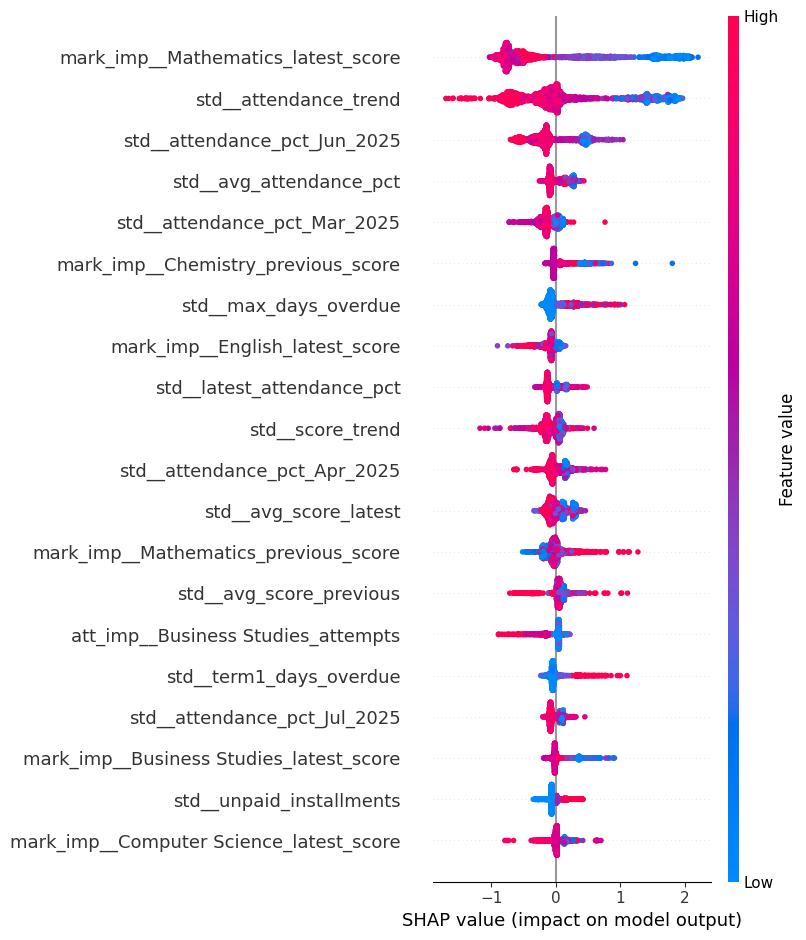

In [26]:
shap.summary_plot(curr_shap_values,x_current_transformed,feature_names=feature_names)

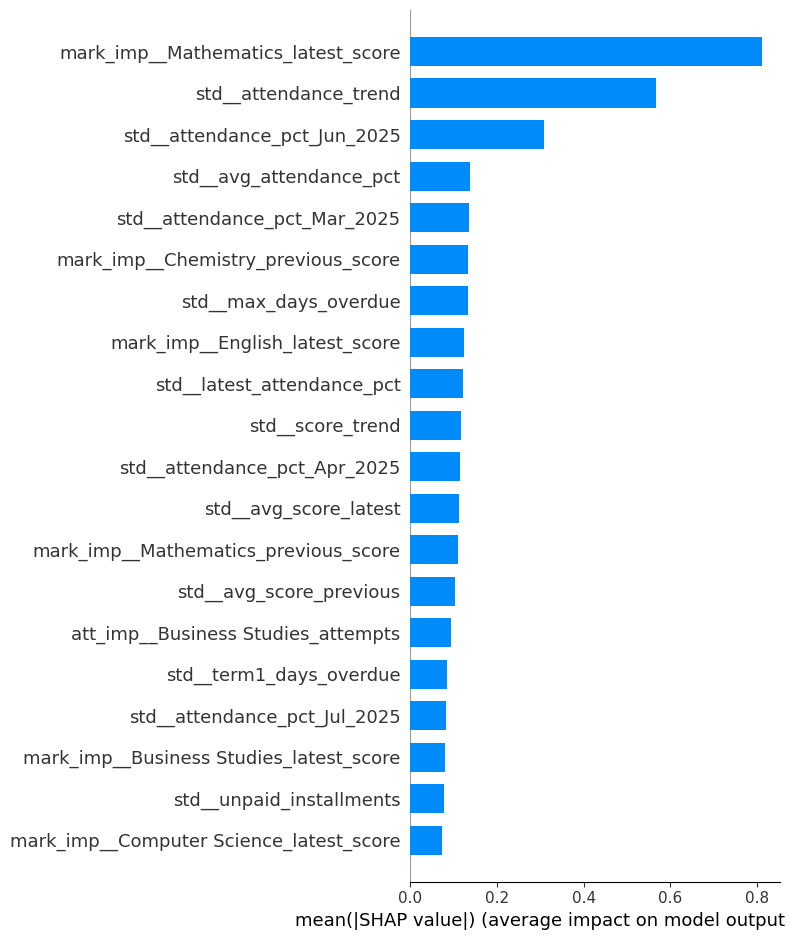

In [27]:
shap.summary_plot(curr_shap_values,x_current_transformed,feature_names=feature_names,plot_type="bar")

In [28]:
student_index = 55

In [29]:
print("Student ID:",df.iloc[student_index]["student_id"])
print("Dropout probability:",y_current_prob[student_index])
print("Prediction:",y_current_pred[student_index])

Student ID: STU10055
Dropout probability: 0.07825741969652655
Prediction: 0


In [30]:
stu_explan = shap.Explanation(values=curr_shap_values[student_index],
                             base_values=explainer.expected_value,
                             data=x_current_transformed[student_index],
                             feature_names=feature_names)

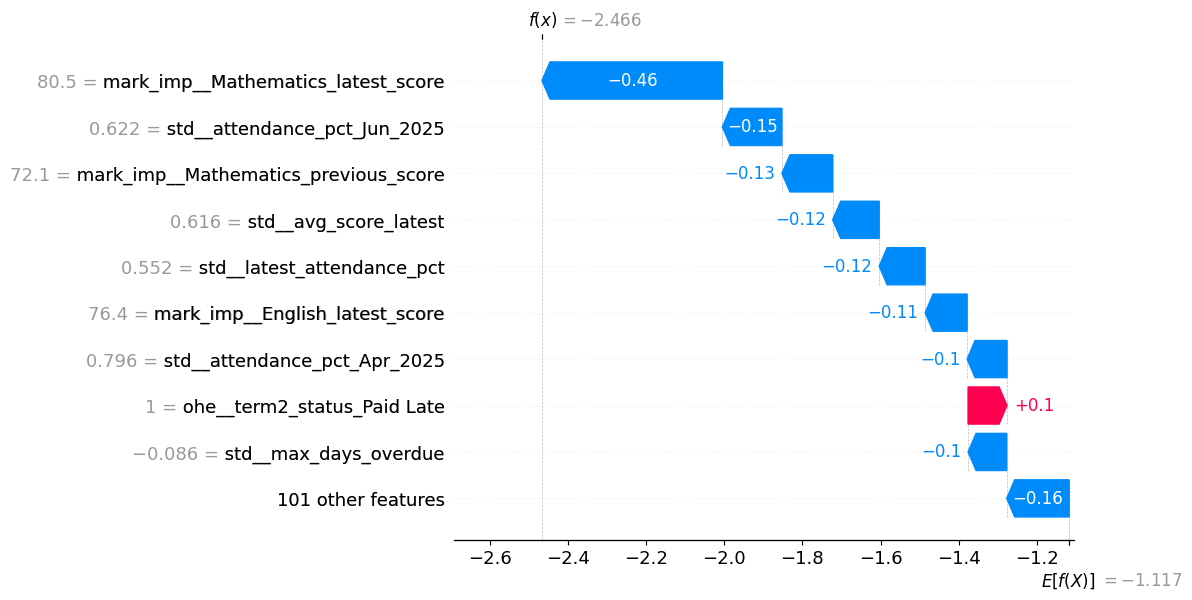

In [31]:
shap.waterfall_plot(stu_explan)

In [32]:
student_shap = pd.DataFrame({
    "Feature" : feature_names,
    "shap values" : curr_shap_values[student_index]
})

In [33]:
def get_original_feature(name):

    name = name.split('__')[-1]

    for col in obj_col:
        if name.startswith(col + '_'):
            return col

    for col in scores:
        if name.startswith(col + '_missing'):
            return col

    return name

In [34]:
student_shap["Original_Feature"] = (student_shap["Feature"].apply(get_original_feature))

In [35]:
risk_factor = student_shap[student_shap["shap values"]>0].sort_values("shap values",ascending=False)

In [36]:
increasing_risk = student_shap[student_shap["shap values"]>0].head(5)

In [37]:
decreasing_risk = student_shap[student_shap["shap values"]<0].sort_values('shap values',ascending=True).head(5)

In [38]:
result_df = pd.DataFrame({
    "student_id" : df["student_id"],
    "dropout_probability" : y_current_prob,
    "dropout_prediction" : y_current_pred
})

In [39]:
result_df = result_df.merge(df[
    ["student_id","student_name","class_section","mentor_name","stream","latest_attendance_pct",
     "avg_attendance_pct","attendance_trend","avg_score_previous","avg_score_latest","score_trend",
     "subjects_failing_now","max_attempts_any_subject","max_days_overdue"]
])

In [40]:
shap_result = []

In [41]:
for i in range(len(x_current)) : 
    student_shap = pd.DataFrame({"Feature":feature_names,"shap values":curr_shap_values[i]})
    student_shap["Original Feature"] = (student_shap["Feature"].apply(get_original_feature))
    agg = (student_shap.groupby("Original Feature")["shap values"].sum().reset_index())
    increasing = (agg[agg["shap values"]>0].sort_values("shap values",ascending=False)).head(5)
    decreasing = (agg[agg["shap values"]<0].sort_values("shap values",ascending=True)).head(5)
    shap_result.append({"student_id":df.iloc[i]["student_id"],
                      "risk_factors":increasing.to_dict("records"),
                      "protective_factors":decreasing.to_dict("records")})

In [42]:
shap_df = pd.DataFrame(shap_result)

In [43]:
final_student_data = result_df.merge(shap_df,on="student_id",how="left")

In [44]:
import json

In [45]:
final_student_data["risk_factors"] = final_student_data["risk_factors"].apply(json.dumps)

In [46]:
final_student_data["protective_factors"] = final_student_data["protective_factors"].apply(json.dumps)

In [47]:
conn = sqlite3.connect(r"C:\Users\01\problem\database\project_current.db")
conn.execute("DROP TABLE IF EXISTS student_risk_scores")

In [48]:
def score_students(students_df, attendance_df, assessments_df, fees_df,
                    model_path="student_risk_model_previous.pkl",
                    threshold_path="threshold.pkl",
                    expected_columns_path="expected_columns.pkl",
                    scores_path="scores.pkl",
                    obj_col_path="obj_col.pkl"):

    df = (students_df
          .merge(attendance_df, on="student_id", how="left")
          .merge(assessments_df, on="student_id", how="left")
          .merge(fees_df, on="student_id", how="left"))

    final_model = joblib.load(model_path)
    threshold = joblib.load(threshold_path)
    expected_columns = joblib.load(expected_columns_path)
    scores = joblib.load(scores_path)
    obj_col = joblib.load(obj_col_path)

    preprocessor = final_model.named_steps["preprocessor"]
    model = final_model.named_steps["model"]

    current_attendance = ['attendance_pct_Feb_2026', 'attendance_pct_Mar_2026', 'attendance_pct_Apr_2026',
                           'attendance_pct_May_2026', 'attendance_pct_Jun_2026', 'attendance_pct_Jul_2026']
    monthly_attendance = ['attendance_pct_Feb_2025', 'attendance_pct_Mar_2025', 'attendance_pct_Apr_2025',
                           'attendance_pct_May_2025', 'attendance_pct_Jun_2025', 'attendance_pct_Jul_2025']
    attendance_mapping = dict(zip(monthly_attendance, current_attendance[:len(monthly_attendance)]))

    X_current = df.copy()
    for old_col, current_col in attendance_mapping.items():
        X_current[old_col] = df[current_col]

    x_current = X_current[expected_columns].copy()

    y_prob = final_model.predict_proba(x_current)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    x_transformed = preprocessor.transform(x_current)
    feature_names = preprocessor.get_feature_names_out()
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x_transformed)

    def get_original_feature(name):
        name = name.split("__")[-1]
        for col in obj_col:
            if name.startswith(col + "_"):
                return col
        for col in scores:
            if name.startswith(col + "_missing"):
                return col
        return name

    shap_result = []
    for i in range(len(x_current)):
        student_shap = pd.DataFrame({"Feature": feature_names, "shap values": shap_values[i]})
        student_shap["Original Feature"] = student_shap["Feature"].apply(get_original_feature)
        agg = student_shap.groupby("Original Feature")["shap values"].sum().reset_index()

        increasing = agg[agg["shap values"] > 0].sort_values("shap values", ascending=False).head(5)
        decreasing = agg[agg["shap values"] < 0].sort_values("shap values", ascending=True).head(5)

        shap_result.append({
            "student_id": df.iloc[i]["student_id"],
            "risk_factors": increasing.to_dict("records"),
            "protective_factors": decreasing.to_dict("records"),
        })

    result_df = pd.DataFrame({
        "student_id": df["student_id"],
        "dropout_probability": y_prob,
        "dropout_prediction": y_pred,
    })
    result_df = result_df.merge(df[[
        "student_id", "student_name", "class_section", "mentor_name", "stream",
        "latest_attendance_pct", "avg_attendance_pct", "attendance_trend",
        "avg_score_previous", "avg_score_latest", "score_trend",
        "subjects_failing_now", "max_attempts_any_subject", "max_days_overdue",
    ]], on="student_id", how="left")

    shap_df = pd.DataFrame(shap_result)
    final_student_data = result_df.merge(shap_df, on="student_id", how="left")

    def apply_rule_thresholds(d):
        rules = pd.DataFrame(index=d.index)
        rules["low_attendance"] = d["avg_attendance_pct"] < 75
        rules["multiple_fails"] = d["subjects_failing_now"] >= 2
        rules["repeated_attempts"] = d["max_attempts_any_subject"] >= 3
        rules["fee_overdue"] = d["max_days_overdue"] > 30
        rules["declining_scores"] = d["score_trend"] < 0

        rules["rule_flag_count"] = rules.sum(axis=1)
        rules["triggered_rules"] = rules.drop(columns="rule_flag_count").apply(
            lambda row: [c for c in row.index if row[c]], axis=1
        )
        return rules[["rule_flag_count", "triggered_rules"]]

    def assign_risk_band(row):
        if row["dropout_prediction"] == 1 or row["rule_flag_count"] >= 2:
            return "red"
        elif row["dropout_probability"] >= 0.3 or row["rule_flag_count"] == 1:
            return "amber"
        return "green"

    rule_results = apply_rule_thresholds(final_student_data)
    final_student_data = pd.concat([final_student_data, rule_results], axis=1)
    final_student_data["risk_band"] = final_student_data.apply(assign_risk_band, axis=1)
    final_student_data["triggered_rules"] = final_student_data["triggered_rules"].apply(json.dumps)

    final_student_data["risk_factors"] = final_student_data["risk_factors"].apply(json.dumps)
    final_student_data["protective_factors"] = final_student_data["protective_factors"].apply(json.dumps)
    final_student_data["scored_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    return final_student_data

In [49]:
import os
print(os.getcwd())

C:\Users\01\problem\notebook


In [50]:
final_result = score_students(students, attendance, assessments, fees)
print(final_result.shape)                          # should be (2000, ~20), not doubled
print(final_result['risk_band'].value_counts())    # should show red/amber/green counts
final_result[['student_id','dropout_probability','rule_flag_count','risk_band']].head(10)

(2000, 22)
risk_band
green    824
red      764
amber    412
Name: count, dtype: int64


,student_id,dropout_probability,rule_flag_count,risk_band
0,STU10000,0.018257,0,green
1,STU10001,0.064768,0,green
2,STU10002,0.068680,0,green
3,STU10003,0.016900,0,green
4,STU10004,0.720823,3,red
5,STU10005,0.803920,2,red
6,STU10006,0.987847,4,red
7,STU10007,0.051031,2,red
8,STU10008,0.075655,0,green
9,STU10009,0.055013,1,amber
